# Prefazione


Questo notebook raccoglie in forma rielaborata la parte di teoria del **Metodo degli Elementi Finiti (FEM)** che ho studiato come preparazione al progetto contenuto in questo repository. Lo scopo è duplice:

- avere un riferimento ordinato e in italiano dei passaggi essenziali, senza dover ogni volta tornare al libro;
- mostrare il filo logico che collega l'approssimazione di funzioni a tratti alla risoluzione numerica di problemi differenziali, così che il codice del progetto non appaia come una scatola nera.

La trattazione segue, in modo non esaustivo, i primi quattro capitoli di

> Mats G. Larson, Fredrik Bengzon. *The Finite Element Method: Theory,
> Implementation, and Applications*. Texts in Computational Science and
> Engineering, vol. 10, Springer, 2013.

I capitoli sono organizzati come segue:

1. **Approssimazione polinomiale a tratti in 1D** — Spazi di funzioni lineari a tratti su un intervallo, base delle *hat functions*, proiezione $L^2$, formula di Simpson per l'assemblaggio di matrice di massa e vettore di arico.
2. **FEM in 1D** — Formulazione debole, problema di Poisson monodimensionale, matrice di rigidezza, imposizione delle condizioni al contorno.
3. **Approssimazione polinomiale a tratti in 2D** — Estensione su mesh triangolari, interpolazione e proiezione $L^2$ in due dimensioni.
4. **FEM in 2D** — Risoluzione di problemi ellittici su domini bidimensionali.

Ogni capitolo è accompagnato da un breve esempio in Python che traduce la teoria in codice, senza alcuna pretesa di efficienza o generalità: servono solo a verificare che i passaggi tornino.

Il **progetto vero e proprio** — risoluzione tramite FEM dell'equazione di Laplace con condizioni al contorno di Dirichlet — si trova nella cartella separata.

### Prerequisiti

Si assume familiarità con calcolo differenziale e integrale, algebra lineare e nozioni di base di spazi funzionali ($L^2$, $H^1$). Per le dimostrazioni complete (esistenza e unicità della proiezione, stime a priori dell'errore, proprietà spettrali delle matrici di massa e rigidezza) si rimanda al testo di riferimento.

### Note

I contenuti sono una rielaborazione personale a scopo di studio: eventuali imprecisioni o sviste sono mie, non del testo originale. Se ne trovi, segnala pure aprendo una *issue*.

# Capitolo 1

### Spazi polinomiali a tratti

Dato $ I = [x_0, x_1] $, definiamo l'insieme $\mathcal{P}_1(I)$ come 

$$

\mathcal{P}_1(I) = \{v : v(x) = c_0 + c_1 x, \ x \in I, \ c_0, c_1 \in \mathbb{R} \}

$$

Una base ovvia è $\{1, x\}$, tuttavia è utile trovare anche una base che dipende dagli estremi dell'intervallo. Consideriamo la base $\{\lambda_0, \lambda_1\}$ tale per cui:

$$
\lambda_j\left(x_i\right)=\left
\{\begin{array}{ll}
1, & \text { if } i=j \\
0, & \text { if } i \neq j
\end{array}, \quad i, j=0,1\right.
$$

Esplicitando questa base 

$$

\lambda_0 = \frac{x_1 - x}{x_1 - x_0} \qquad \lambda_1 = \frac{x - x_0}{x_1 - x_0}

$$

Se suddividiamo l'intervallo iniziale in $n$ sottointervalli $I_i = [x_{i-1}, x_{i}] \, \ i = \{1, 2, \dots, n\}$, ciascuno di lunghezza $h_i = x_i - x_{i-1}$, tale che:

$$

x_0 < x_1 < \dots < x_n

$$

Possiamo definire un altro spazio vettoriale:

$$

V_h = \{ v: v \in \mathcal{C}^0 (I), \ v|_{I_i} \in \mathcal{P}_1 (I_i) \}

$$

Si nota che il valore di un elemento nei nodi identifica in modo univoco la $v \in V_h$, allora possiamo usare come base di $V_h$ la base $\{ \varphi_0, \varphi_1, \dots, \varphi_n \}$ tale che:

$$
\varphi_j\left(x_i\right)=\left
\{\begin{array}{ll}
1, & \text { if } i=j \\
0, & \text { if } i \neq j
\end{array}, \quad i, j=0,1\right.
$$

Esplicitando 

$$
\varphi_i= \begin{cases}\left(x-x_{i-1}\right) / h_i, & \text { if } x \in I_i \\ \left(x_{i+1}-x\right) / h_{i+1}, & \text { if } x \in I_{i+1} \\ 0, & \text { altrimenti }\end{cases}
$$

### Proiezioni - $L^2$ (Approssimazioni di funzioni continue)

Andiamo a cercare un modo per approssimare funzioni continue definite su un intervallo $I$.

Consideriamo $f \in L^2(I)$, definiamo la proiezione-$L^2$ $P_h f \in V_h$ di $f$ come:

$$

\int_I (f - P_h f) \, v \, dx = 0 \qquad \forall v \in V_h \qquad (1.1)

$$

Questa, in realtà, è un'analogia con le proiezioni su un sottospazio $\mathbb{R}^n$.

<div style="text-align: center;">
    <img src="Foto/proiezione_L2.png" alt="Proiezione L²" width="400">
</div>

Non ci resta che trovare un algoritmo per ottenere $P_h f$.
Dato che la (1.1) deve valere $\forall v \in V_h$ è sufficiente che valga per gli elementi della base, inoltre sappiamo che $P_h f \in V_h$, allora si ha

$$

P_h f = \sum_{j=0}^{n} \xi_j \varphi_j

$$

Allora possiamo riscrivere la (1.1) come

$$

\int_I \left(f - \sum_{j=0}^{n} \xi_j \varphi_j \right) \varphi_i \, dx = 0

$$

$$

\to \int_I f \varphi_i \, dx = \sum_{j=0}^{n} \xi_j \int_I \varphi_j \varphi_i \, dx \qquad (1.2)

$$

Allora possiamo definire

$$

b_i = \int_I f \varphi_i \, dx \qquad M_{ij} = \int_I \varphi_j \varphi_i \, dx

$$

In questo modo la (1.2) diventa

$$

b = M \xi \qquad (1.3)

$$

Quindi, una volta esplicitati $b$ e $M$, basta risolvere il sistema (1.3) e trovare $\xi$ per ottenere $P_h f$.

Teoricamente per trovare $b$ e $M$ potremmo andare a integrare, tuttavia possiamo rendere il calcolo degli integrali più veloce e automatico tramite la formula di Simpson.

> **Formula di Simpson**
>
> Consideriamo una funzione $f$ definita nell'intervallo $[0, h]$. Se voglio calcolare $\int_0^h f \, dx$ è ragionevole approssimare $f$ a una funzione $g(x) = c_0 + c_1 x + c_2 x^2$ tale per cui $g(0) = f(0)$, $g(h/2) = f(h/2)$ e $g(h) = f(h)$.
>
> Risolvendo il sistema si ha
>
> $$
> c_2 = \frac{2(f(0) - 2 f(h/2) + f(h))}{h^2} \qquad c_1 = -\frac{3f(0) - 4 f(h/2) + f(h)}{h} \qquad c_0 = f(0)
> $$
>
> Allora
>
> $$
> \int_0^h f \, dx \approx \int_0^h g(x) \, dx = \frac{f(0) + 4 f(h/2) + f(h)}{6} \, h
> $$
>
> Generalizzando a un intervallo $I = (a, b)$ si ha
>
> $$
> \int_a^b f \, dx \approx \frac{f(a) + 4 f\!\left(\frac{1}{2}(a+b)\right) + f(b)}{6} \, (b - a)
> $$

Utilizziamo questo metodo per trovare $M$:

i)

$$

M_{ii} = \int_I \varphi_i^2 \, dx = \int_{x_{i-1}}^{x_i} \varphi_i^2 \, dx + \int_{x_i}^{x_{i+1}} \varphi_i^2 \, dx

$$

$$

= \frac{0 + 4 \cdot \left(\frac{1}{2}\right)^2 + 1}{6} \, h_i + \frac{1 + 4 \cdot \left(\frac{1}{2}\right)^2 + 0}{6} \, h_{i+1}

$$

$$

= \frac{h_i}{3} + \frac{h_{i+1}}{3} \qquad i = 1, 2, \dots, n-1

$$

ii)

$$

M_{i+1, \, i} = \int_I \varphi_i \cdot \varphi_{i+1} \, dx = \int_{x_i}^{x_{i+1}} \varphi_i \, \varphi_{i+1} \, dx

$$

$$

= \frac{1 \cdot 0 + 4 \cdot \left(\frac{1}{2}\right)^2 + 0}{6} \, h_{i+1} = \frac{h_{i+1}}{6}

$$

Questi elementi sono sufficienti in quanto per $|i - j| > 1$, $\varphi_i \varphi_j = 0$ e $M_{ij}$ è simmetrica.

$$

\to M = \begin{pmatrix}
\frac{h_1}{3} & \frac{h_1}{6} & & & \\[4pt]
\frac{h_1}{6} & \frac{h_1}{3} + \frac{h_2}{3} & \frac{h_2}{6} & & \\[4pt]
& \frac{h_2}{6} & \frac{h_2}{3} + \frac{h_3}{3} & \ddots & \\[4pt]
& & \ddots & \frac{h_{n-1}}{3} + \frac{h_n}{3} & \frac{h_n}{6} \\[4pt]
& & & \frac{h_n}{6} & \frac{h_n}{3}
\end{pmatrix}

$$

Utilizziamo lo stesso metodo per trovare $b$:

$$

b_i = \int_I f \varphi_i \, dx = \int_{x_{i-1}}^{x_i} f \varphi_i \, dx + \int_{x_i}^{x_{i+1}} f \varphi_i \, dx

$$

$$

\approx \big(f(x_{i-1}) \varphi_i(x_{i-1}) + f(x_i) \varphi_i(x_i)\big) \frac{h_i}{2} + \big(f(x_i) \varphi_i(x_i) + f(x_{i+1}) \varphi_i(x_{i+1})\big) \frac{h_{i+1}}{2}

$$

$$

= f(x_i) \, \frac{h_i + h_{i+1}}{2}

$$

Allora

$$

b = \begin{pmatrix}
f(x_0) \, h_1 / 2 \\[4pt]
f(x_1) \, (h_1 + h_2)/2 \\[4pt]
\vdots \\[4pt]
f(x_{n-1}) \, (h_{n-1} + h_n)/2 \\[4pt]
f(x_n) \, h_n / 2
\end{pmatrix}

$$

Quindi per trovare $P_h f$ ci basta trovare $\xi$ risolvendo il sistema $b = M \xi$.

#### Esempio

Riportiamo un esempio in cui è stato utilizzato questo algoritmo

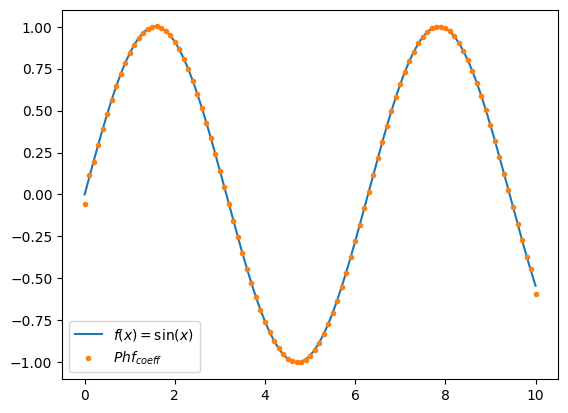

In [1]:
import numpy as np
from matplotlib import pyplot as plt

# ------ Andiamo a trovare Phf, posto f = sin(x) considerando n nodi equidistanti a due a due -------- 

# Consideriamo l'intervallo I = [x_a, x_b]
x_a, x_b = [0, 10]
n = 100
lunghezza_I = x_b - x_a
H = np.linspace(x_a, x_b, n+1) # array dei nodi
h = lunghezza_I/n # lunghezza di ciascun sottointervallo 

# Funzione presa in esame
def f(x):
    return np.sin(x)

# Troviamo la matrice M 
M = np.zeros((n+1,n+1))

for i in range(n):
    M[i][i] += h/3
    M[i+1][i] += h/6
    M[i][i+1] += h/6
    M[i+1][i+1] += h/3

# Troviamo il vettore b
b = np.zeros(n+1)

for i in range(n):
    b[i] += f(H[i])*h/2
    b[i+1] += f(H[i+1])*h/2

# Risolviamo il sistema 
Phf = np.linalg.solve(M, b)

#Plot dei risultati 
asse_x = np.linspace(x_a, x_b, 1000)

plt.plot(asse_x, f(asse_x), label = "$f(x) = \\sin(x)$")
plt.errorbar(H, Phf, fmt=".", label = "$Phf_{coeff}$")
plt.legend()
plt.show()